# Train — Smartphone (object detector)

Training YOLO26m deteksi objek `smartphone` (1 kelas). Prasyarat: jalankan **`01_data.ipynb`**.

**Output:** `best.pt` di `research/runs/detect/smartphone_yolo26m/weights/`.

Model ini dipakai pipeline kompositional `holding_phone_count` (person+pose+phone+walking),
BUKAN check sendiri. Registrasi: lihat sel terakhir.

> ⚠️ Dataset = foto close-up (lihat 01_data). `TRAIN_CFG` di bawah pakai **scale-down kuat**
> (`scale=0.9`) + mosaic untuk *mensimulasikan* HP kecil. Ini mitigasi parsial — tidak bisa
> menggantikan data CCTV asli. Ukur recall, jangan kaget kalau rendah di frame jauh.

## Setup

In [1]:
%matplotlib inline
from __future__ import annotations

import contextlib
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from ultralytics import YOLO

NOTEBOOK_DIR = Path.cwd()
RESEARCH_DIR = NOTEBOOK_DIR.parents[1]
AI_DIR       = NOTEBOOK_DIR.parents[2]

PROC_DIR  = RESEARCH_DIR / 'datasets' / 'processed' / 'smartphone'
DATA_YAML = PROC_DIR / 'data.yaml'
BASE_MODEL = AI_DIR / 'models' / 'yolo26m.pt'
RUNS_DIR = RESEARCH_DIR / 'runs' / 'detect'
ARTIFACTS_DIR = RESEARCH_DIR / 'artifacts' / 'smartphone'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = 'smartphone_yolo26m'
SEED = 42
CLASS_NAMES = ['smartphone']

if not DATA_YAML.exists():
    raise FileNotFoundError(f'data.yaml nggak ada: {DATA_YAML}. Jalankan 01_data.ipynb dulu.')
if not BASE_MODEL.exists():
    raise FileNotFoundError(f'Base model nggak ada: {BASE_MODEL}')
print('data.yaml  :', DATA_YAML)
print('Base model :', BASE_MODEL)

data.yaml  : c:\Users\istd.magang125\OneDrive - TMMIN\Documents\cctv-insight\ai\research\datasets\processed\smartphone\data.yaml
Base model : c:\Users\istd.magang125\OneDrive - TMMIN\Documents\cctv-insight\ai\models\yolo26m.pt


## Training

Set `RUN_TRAINING=True` untuk training (default True karena memang tujuan notebook ini).
`scale=0.9` = objek bisa mengecil hingga ~0.1x (simulasi HP jauh); `exist_ok=True` menimpa
run lama supaya `weights_path` di registry tetap valid.

In [2]:
RUN_TRAINING = False

TRAIN_CFG = {
    'epochs': 100,
    'imgsz': 640,
    'batch': 8,
    'workers': 4,
    'patience': 30,
    'seed': SEED,
    'cos_lr': True,
    'close_mosaic': 10,
    # --- augmentasi: scale-down KUAT untuk lawan bias close-up dataset ---
    'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4,
    'degrees': 10.0, 'translate': 0.1, 'scale': 0.9, 'shear': 3.0,
    'fliplr': 0.5, 'mosaic': 1.0, 'mixup': 0.1,
    'project': str(RUNS_DIR),
    'name': RUN_NAME,
    'exist_ok': True,
}


@contextlib.contextmanager
def _cwd(path):
    prev = os.getcwd(); os.chdir(str(path))
    try:
        yield
    finally:
        os.chdir(prev)


if RUN_TRAINING:
    with _cwd(AI_DIR / 'models'):
        model = YOLO(str(BASE_MODEL))
        result = model.train(data=str(DATA_YAML), **TRAIN_CFG)
    print('Training kelar:', result.save_dir)
else:
    print('Training di-skip. Set RUN_TRAINING=True kalau mau training.')

Training di-skip. Set RUN_TRAINING=True kalau mau training.


## Evaluasi

In [3]:
def find_latest_run(prefix):
    cands = [d for d in RUNS_DIR.glob(f'{prefix}*')
             if d.is_dir() and (d / 'weights' / 'best.pt').exists()]
    if not cands:
        raise FileNotFoundError(f"Belum ada run '{prefix}' di {RUNS_DIR}. Training dulu.")
    return max(cands, key=lambda d: d.stat().st_mtime)

run_dir = find_latest_run(RUN_NAME)
best_pt = run_dir / 'weights' / 'best.pt'
results_csv = run_dir / 'results.csv'
eval_model = YOLO(str(best_pt))
print('Run dir:', run_dir, '| kelas:', eval_model.names)

val = eval_model.val(data=str(DATA_YAML), imgsz=640, conf=0.25, verbose=False)
metrics = {
    'mAP50': round(float(val.box.map50), 3),
    'mAP50-95': round(float(val.box.map), 3),
    'Precision': round(float(val.box.mp), 3),
    'Recall': round(float(val.box.mr), 3),
}
print(pd.DataFrame([metrics]).to_string(index=False))

Run dir: c:\Users\istd.magang125\OneDrive - TMMIN\Documents\cctv-insight\ai\research\runs\detect\smartphone_yolo26m | kelas: {0: 'smartphone'}
Ultralytics 8.4.38  Python-3.14.3 torch-2.12.1+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 7.41.8 MB/s, size: 25.8 KB)
val: Scanning C:\Users\istd.magang125\OneDrive - TMMIN\Documents\cctv-insight\ai\research\datasets\processed\smartphone\valid\labels.cache... 296 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 296/296 49.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 2.2it/s 8.5s0.4s
                   all        296        338      0.954      0.941      0.965      0.754
Speed: 1.5ms preprocess, 23.6ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to C:\Users\istd.magang125\Documents\backend\runs\de

## Training curves + sample prediksi

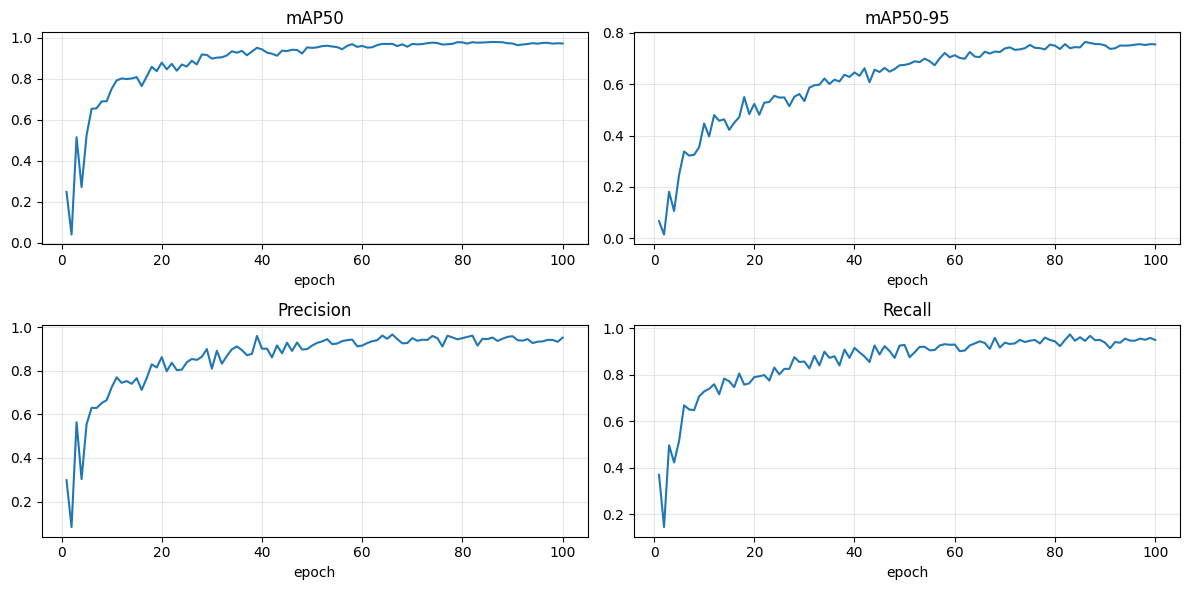

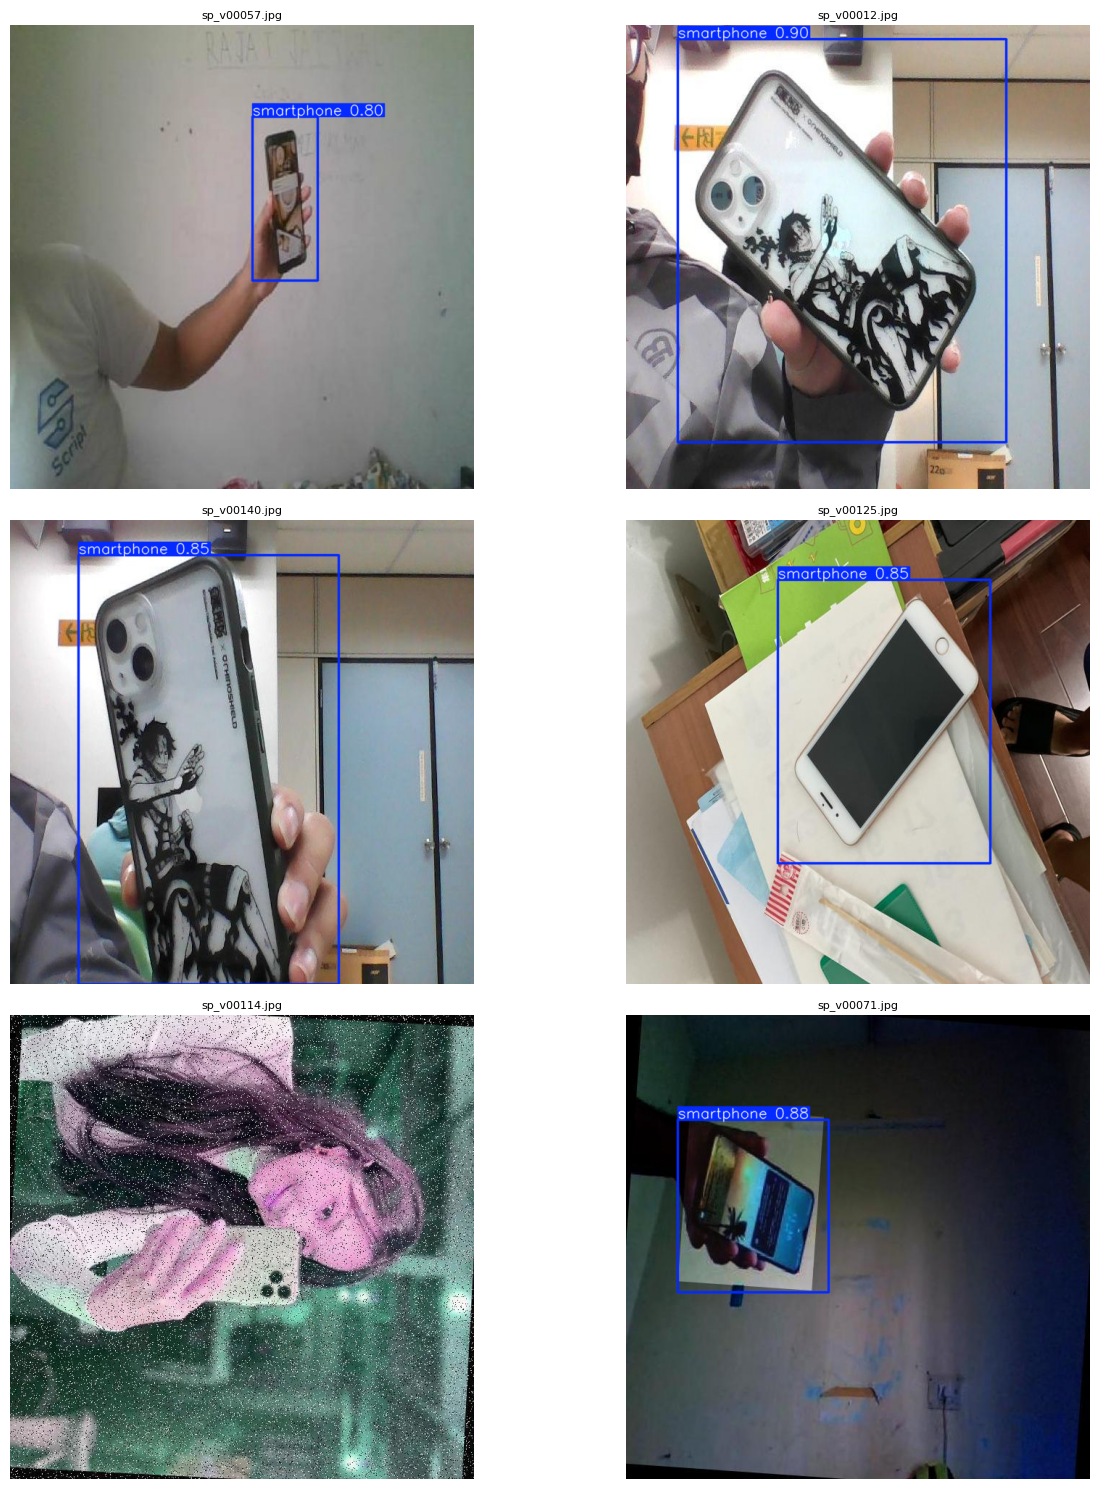

In [4]:
df = pd.read_csv(results_csv); df.columns = [c.strip() for c in df.columns]
curves = [('metrics/mAP50(B)', 'mAP50'), ('metrics/mAP50-95(B)', 'mAP50-95'),
          ('metrics/precision(B)', 'Precision'), ('metrics/recall(B)', 'Recall')]
available = [(c, l) for c, l in curves if c in df.columns]
fig, axes = plt.subplots(2, 2, figsize=(12, 6)); axes = axes.flatten()
for ax, (col, label) in zip(axes, available):
    ax.plot(df['epoch'], df[col]); ax.set_title(label); ax.set_xlabel('epoch'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

N = 6
val_dir = PROC_DIR / 'valid' / 'images'
imgs = []
for e in ('*.jpg', '*.jpeg', '*.png'):
    imgs.extend(sorted(val_dir.glob(e)))
samples = random.Random(SEED).sample(imgs, min(N, len(imgs)))
cols = 2; rows_n = (len(samples) + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(14, 5 * rows_n)); axes = axes.flatten()
for ax, ip in zip(axes, samples):
    r = eval_model.predict(str(ip), conf=0.25, imgsz=640, verbose=False)[0]
    ax.imshow(r.plot()[..., ::-1]); ax.set_title(ip.name[:40], fontsize=8); ax.axis('off')
for ax in axes[len(samples):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## Simpan artifact

In [5]:
import json
import torch

speed = getattr(val, 'speed', {}) or {}
total_ms = sum(float(speed.get(k, 0.0)) for k in ('preprocess', 'inference', 'postprocess'))
eval_report = {
    'model_key': 'smartphone',
    'base_weight': str(BASE_MODEL),
    'run_dir': str(run_dir), 'best_pt': str(best_pt), 'data_yaml': str(DATA_YAML),
    'class_names': CLASS_NAMES, 'seed': SEED, 'train_cfg': TRAIN_CFG,
    'eval_cfg': {'conf': 0.25, 'imgsz': 640, 'split': 'val'},
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'metrics': {'mAP50': float(val.box.map50), 'mAP50-95': float(val.box.map),
                'precision': float(val.box.mp), 'recall': float(val.box.mr)},
    'speed_ms': {'total': total_ms, 'fps': (1000.0 / total_ms) if total_ms else 0.0},
}
(ARTIFACTS_DIR / 'eval_report.json').write_text(json.dumps(eval_report, indent=2), encoding='utf-8')
print('Saved ke', ARTIFACTS_DIR)

Saved ke c:\Users\istd.magang125\OneDrive - TMMIN\Documents\cctv-insight\ai\research\artifacts\smartphone


## Cara register ke service

Beda dari model lain: `smartphone` **bukan** check sendiri — ia komponen pipeline
`holding_phone_count`. Cukup daftarkan MODEL-nya di
[registry.py](../../../src/cctv_insight_ai/models/registry.py); routing + post-processing
(asosiasi person↔phone, kepala-menunduk, walking) dikerjakan di `pipelines/infer.py` (Fase 2).

```python
"smartphone": ModelSpec(
    name="smartphone_yolo26m",
    version="2026.06.21",
    weights_path=str(_RUNS_DIR / "smartphone_yolo26m" / "weights" / "best.pt"),
    task_classes=[0],
    class_labels={0: ClassLabel("smartphone")},
    description="Smartphone object detector; feeds holding_phone_count composite",
),
```

Setelah `best.pt` ada, beri tahu saya — saya lanjut Fase 2 (kode integrasi + test).